# Phase 2 - Neural Network
fake news detection - building and improving a dense neural network

## Section 1 - Imports

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, classification_report

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print('done')

done


## Section 2 - Load and Prepare Data
same loading and cleaning as phase 1
same split ratio: 70/15/15, random_state=42
same TfidfVectorizer(max_features=10000) - fit on train only, no leakage

In [42]:
fake = pd.read_csv('data/raw/Fake.csv')
real = pd.read_csv('data/raw/True.csv')

fake['label'] = 'FAKE'
real['label'] = 'REAL'

df = pd.concat([fake, real], ignore_index=True)
print(df.shape)
display(df.head())

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = (df['title'] + ' ' + df['text']).apply(clean_text)
df['label_enc'] = (df['label'] == 'REAL').astype(int)

display(df.head())

X = df['clean_text'].values
y = df['label_enc'].values

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=RANDOM_STATE)
X_val,   X_test, y_val,   y_test  = train_test_split(X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE)

print('train:', X_train.shape, '| val:', X_val.shape, '| test:', X_test.shape)

(44898, 5)


,title,text,subject,date,label
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",FAKE
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",FAKE
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",FAKE
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",FAKE
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",FAKE


,title,text,subject,date,label,clean_text,label_enc
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",FAKE,donald trump sends out embarrassing new year s...,0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",FAKE,drunk bragging trump staffer started russian c...,0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",FAKE,sheriff david clarke becomes an internet joke ...,0
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",FAKE,trump is so obsessed he even has obama s name ...,0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",FAKE,pope francis just called out donald trump duri...,0


train: (31428,) | val: (6735,) | test: (6735,)


## Section 3 - TF-IDF Vectorizer
fit on train only - no data leakage

In [43]:
tfidf = TfidfVectorizer(max_features=10000)
X_train_vec = tfidf.fit_transform(X_train).toarray()
X_val_vec   = tfidf.transform(X_val).toarray()
X_test_vec  = tfidf.transform(X_test).toarray()

print('TF-IDF shape:', X_train_vec.shape)

TF-IDF shape: (31428, 10000)


## Section 4 - Baseline Model (Dense + TF-IDF)

In [44]:
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(10000,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\mmmal\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 128)            │     1,280,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,288,449 (4.92 MB)

 Trainable params: 1,288,449 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
history_baseline = model.fit(
    X_train_vec, y_train,
    validation_data=(X_val_vec, y_val),
    epochs=15,
    batch_size=128,
    verbose=1
)

Epoch 1/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9707 - loss: 0.1169 - val_accuracy: 0.9903 - val_loss: 0.0326
Epoch 2/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9976 - loss: 0.0092 - val_accuracy: 0.9927 - val_loss: 0.0275
Epoch 3/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9998 - loss: 0.0019 - val_accuracy: 0.9912 - val_loss: 0.0292
Epoch 4/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 1.0000 - loss: 4.2763e-04 - val_accuracy: 0.9923 - val_loss: 0.0303
Epoch 5/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 1.0000 - loss: 1.9050e-04 - val_accuracy: 0.9927 - val_loss: 0.0310
Epoch 6/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 1.0000 - loss: 1.1382e-04 - val_accuracy: 0.9927 - val_loss: 0.0321
Epoch 7/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 1.0000 - loss: 7.5178e-05 - val_accuracy: 0.9927 - val_loss: 0.0331
Epoch 8/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 1.0000 - loss: 5

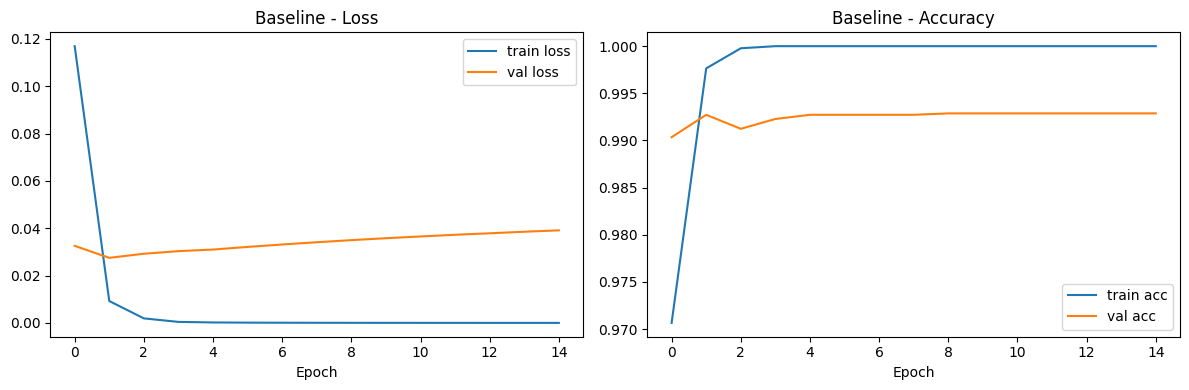

In [46]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['loss'],     label='train loss')
plt.plot(history_baseline.history['val_loss'], label='val loss')
plt.title('Baseline - Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['accuracy'],     label='train acc')
plt.plot(history_baseline.history['val_accuracy'], label='val acc')
plt.title('Baseline - Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

### Overfitting Analysis - Baseline

looking at the curves above:
- if train loss keeps decreasing but val loss starts going up so overfitting is happening
- the gap between train accuracy and val accuracy shows how bad the overfitting is
- since we have no regularization, the model might memorize training data


## Section 5 - Improved Model 

1. **Dropout(0.4)** - randomly turns off 40% of neurons each step so it forces generalization
2. **L2 regularization** - penalizes large weights+
3. **EarlyStopping** - stops training automatically when val_loss stops improving 

In [47]:
model_improved = keras.Sequential([
    layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001),
                 input_shape=(X_train_vec.shape[1],)),
    layers.Dropout(0.4),
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

model_improved.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_improved.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                │ (None, 128)            │     1,280,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,288,449 (4.92 MB)

 Trainable params: 1,288,449 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

In [48]:
# EarlyStopping - stop when val_loss stops improving
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

# train
history_improved = model_improved.fit(
    X_train_vec, y_train,
    validation_data=(X_val_vec, y_val),
    epochs=15,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

# evaluate baseline and improved on val set
baseline_preds = (model.predict(X_val_vec) > 0.5).astype(int).flatten()
baseline_f1    = round(f1_score(y_val, baseline_preds), 4)

improved_preds = (model_improved.predict(X_val_vec) > 0.5).astype(int).flatten()
improved_f1    = round(f1_score(y_val, improved_preds), 4)

print('baseline val F1:', baseline_f1)
print('improved val F1:', improved_f1)


Epoch 1/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9569 - loss: 0.3053 - val_accuracy: 0.9903 - val_loss: 0.1658
Epoch 2/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.9876 - loss: 0.1541 - val_accuracy: 0.9871 - val_loss: 0.1451
Epoch 3/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.9891 - loss: 0.1376 - val_accuracy: 0.9905 - val_loss: 0.1295
Epoch 4/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.9892 - loss: 0.1276 - val_accuracy: 0.9887 - val_loss: 0.1275
Epoch 5/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.9901 - loss: 0.1227 - val_accuracy: 0.9909 - val_loss: 0.1180
Epoch 6/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9903 - loss: 0.1199 - val_accuracy: 0.9899 - val_loss: 0.1191
Epoch 7/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9912 - loss: 0.1170 - val_accuracy: 0.9896 - val_loss: 0.1181
Epoch 8/15
246/246 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9914 - loss: 0.1135 - val_accu

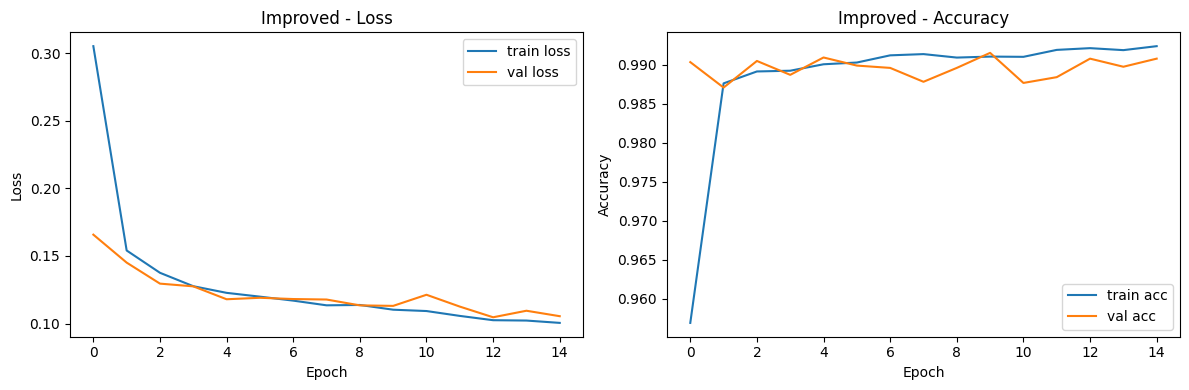

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_improved.history['loss'],     label='train loss')
axes[0].plot(history_improved.history['val_loss'], label='val loss')
axes[0].set_title('Improved - Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_improved.history['accuracy'],     label='train acc')
axes[1].plot(history_improved.history['val_accuracy'], label='val acc')
axes[1].set_title('Improved - Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

### Baseline vs Improved

after adding Dropout, L2, and EarlyStopping:
- the gap between train and val accuracy should be smaller - less overfitting
- EarlyStopping stopped training at the best point before the model started memorizing
- Dropout forces each neuron to be useful on its own instead of relying on others
- L2 keeps the weights small which prevents the model from fitting to noise

## Section 6 - Transfer Learning with GloVe
using pretrained GloVe 50d vectors (glove.6B.50d.txt)

two steps:
1. frozen embedding  - train only the Dense layers
2. fine-tune         - unfreeze embedding and train all

### Step 6.1 - Tokenize Text

In [50]:
MAX_WORDS = 10000
MAX_LEN   = 200
EMBED_DIM = 50       

tokenizer = Tokenizer(num_words=MAX_WORDS)
tokenizer.fit_on_texts(X_train)   # fit on train only - no leakage

X_train_seq = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN)
X_val_seq   = pad_sequences(tokenizer.texts_to_sequences(X_val),   maxlen=MAX_LEN)
X_test_seq  = pad_sequences(tokenizer.texts_to_sequences(X_test),  maxlen=MAX_LEN)

print('train seq shape:', X_train_seq.shape)

train seq shape: (31428, 200)


### Step 6.2 - Load GloVe Vectors

In [51]:
GLOVE_PATH = 'data/raw/glove.6B.50d.txt'

glove_vectors = {}
with open(GLOVE_PATH, encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word   = values[0]
        vector = np.array(values[1:], dtype='float32')
        glove_vectors[word] = vector

print('loaded GloVe vectors:', len(glove_vectors))

loaded GloVe vectors: 400000


### Step 6.3 - Build Embedding Matrix

In [52]:
word_index       = tokenizer.word_index
embedding_matrix = np.zeros((MAX_WORDS, EMBED_DIM))

found = 0
for word, i in word_index.items():
    if i < MAX_WORDS:
        vec = glove_vectors.get(word)
        if vec is not None:
            embedding_matrix[i] = vec
            found += 1

print(f'embedding matrix shape: {embedding_matrix.shape}')
print(f'words covered by GloVe: {found} / {min(len(word_index), MAX_WORDS)}')

embedding matrix shape: (10000, 50)
words covered by GloVe: 9930 / 10000


### Step 6.4 - Frozen Embedding (trainable=False)

In [53]:
model_glove = keras.Sequential([
    layers.Embedding(MAX_WORDS, EMBED_DIM,
                     weights=[embedding_matrix],
                     input_length=MAX_LEN,
                     trainable=False),      # frozen - GloVe weights stay fixed
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

model_glove.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_glove.summary()

c:\Users\mmmal\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,000 (1.91 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 500,000 (1.91 MB)

In [54]:
early_stop_frozen = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_frozen = model_glove.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=20, batch_size=128,
    callbacks=[early_stop_frozen], verbose=1
)

frozen_preds = (model_glove.predict(X_val_seq) > 0.5).astype(int).flatten()
frozen_f1    = round(f1_score(y_val, frozen_preds), 4)
print('frozen embedding val F1:', frozen_f1)

Epoch 1/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8187 - loss: 0.4476 - val_accuracy: 0.8766 - val_loss: 0.3277
Epoch 2/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8806 - loss: 0.3170 - val_accuracy: 0.8888 - val_loss: 0.2823
Epoch 3/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8896 - loss: 0.2866 - val_accuracy: 0.8928 - val_loss: 0.2655
Epoch 4/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8954 - loss: 0.2734 - val_accuracy: 0.8938 - val_loss: 0.2548
Epoch 5/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8971 - loss: 0.2648 - val_accuracy: 0.8980 - val_loss: 0.2477
Epoch 6/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8988 - loss: 0.2577 - val_accuracy: 0.9010 - val_loss: 0.2415
Epoch 7/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9017 - loss: 0.2518 - val_accuracy: 0.9029 - val_loss: 0.2376
Epoch 8/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9025 - loss: 0.2481 - val_accuracy: 0.

### Step 6.5 - Fine-tune (trainable=True)

In [55]:
# unfreeze the embedding layer and fine-tune with a smaller learning rate
model_glove.layers[0].trainable = True

model_glove.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

early_stop_ft = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_finetuned = model_glove.fit(
    X_train_seq, y_train,
    validation_data=(X_val_seq, y_val),
    epochs=20, batch_size=128,
    callbacks=[early_stop_ft], verbose=1
)

finetuned_preds = (model_glove.predict(X_val_seq) > 0.5).astype(int).flatten()
finetuned_f1    = round(f1_score(y_val, finetuned_preds), 4)
print('fine-tuned val F1:', finetuned_f1)

Epoch 1/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9165 - loss: 0.2123 - val_accuracy: 0.9240 - val_loss: 0.1892
Epoch 2/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9260 - loss: 0.1919 - val_accuracy: 0.9316 - val_loss: 0.1735
Epoch 3/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9317 - loss: 0.1748 - val_accuracy: 0.9372 - val_loss: 0.1606
Epoch 4/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9395 - loss: 0.1609 - val_accuracy: 0.9418 - val_loss: 0.1495
Epoch 5/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9442 - loss: 0.1495 - val_accuracy: 0.9479 - val_loss: 0.1403
Epoch 6/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9490 - loss: 0.1384 - val_accuracy: 0.9514 - val_loss: 0.1325
Epoch 7/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9514 - loss: 0.1302 - val_accuracy: 0.9546 - val_loss: 0.1256
Epoch 8/20
246/246 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9553 - loss: 0.1214 - val_accuracy: 0.

### Step 6.6 - Plot GloVe Training Curves

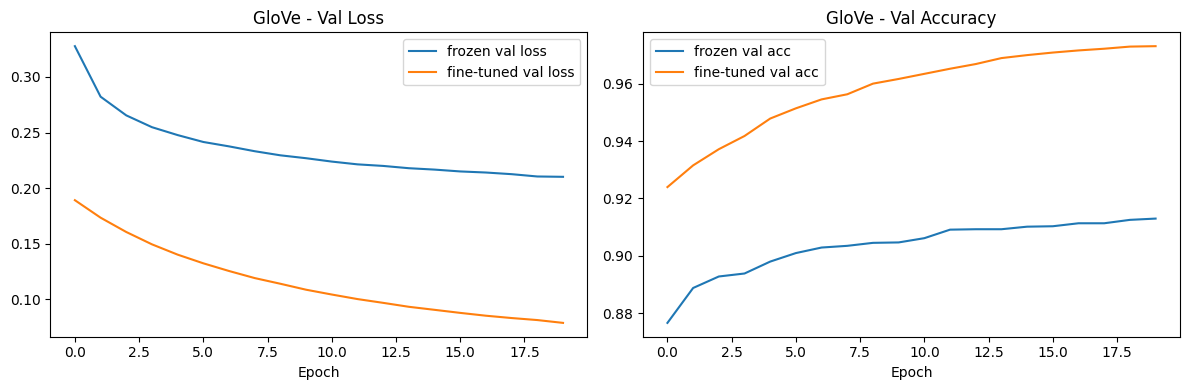

In [56]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_frozen.history['val_loss'],    label='frozen val loss')
plt.plot(history_finetuned.history['val_loss'], label='fine-tuned val loss')
plt.title('GloVe - Val Loss')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_frozen.history['val_accuracy'],    label='frozen val acc')
plt.plot(history_finetuned.history['val_accuracy'], label='fine-tuned val acc')
plt.title('GloVe - Val Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

Initially, I set `epochs=10` for both the frozen and fine-tuned steps.
However, looking at the training curves, the model was still improving at epoch 10
and **EarlyStopping never triggered** - meaning 10 epochs were not enough.

To give the model more room to learn, I increased `epochs=20`.
This allows EarlyStopping to find the true optimal stopping point automatically but the same happened so i will stay on 20 epochs 

## Section 7 - Results Summary
compare all models on validation F1

                model  val_F1
    Baseline (TF-IDF)  0.9925
Improved (Dropout+L2)  0.9902
         GloVe Frozen  0.9090
     GloVe Fine-tuned  0.9717


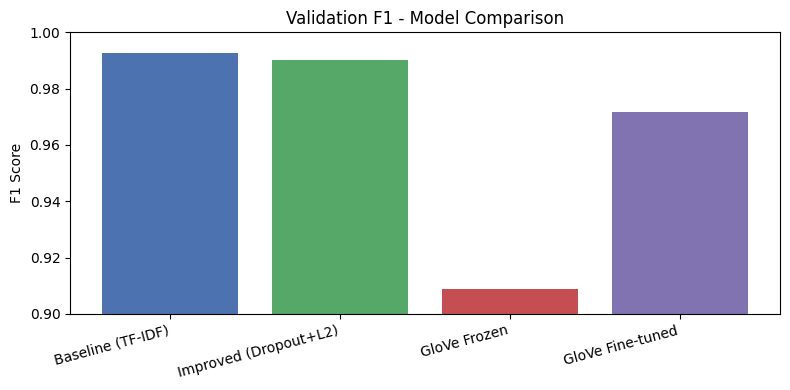

In [57]:
results = pd.DataFrame({
    'model':  ['Baseline (TF-IDF)', 'Improved (Dropout+L2)', 'GloVe Frozen', 'GloVe Fine-tuned'],
    'val_F1': [baseline_f1, improved_f1, frozen_f1, finetuned_f1]
})

print(results.to_string(index=False))

# bar chart
plt.figure(figsize=(8, 4))
plt.bar(results['model'], results['val_F1'], color=['#4C72B0','#55A868','#C44E52','#8172B2'])
plt.ylim(0.9, 1.0)
plt.title('Validation F1 - Model Comparison')
plt.ylabel('F1 Score')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

## Section 8 - Final Evaluation on Test Set
evaluate the best model on the held-out test set

In [59]:
# use whichever model had the best val F1
best_idx   = results['val_F1'].idxmax()
best_model_name = results.loc[best_idx, 'model']
print('Best model:', best_model_name)

# pick the right test input
if 'GloVe' in best_model_name:
    test_input = X_test_seq
    best_model = model_glove
elif 'Improved' in best_model_name:
    test_input = X_test_vec
    best_model = model_improved
else:
    test_input = X_test_vec
    best_model = model

test_preds = (best_model.predict(test_input) > 0.5).astype(int).flatten()
test_f1    = round(f1_score(y_test, test_preds), 4)
print('Test F1:', test_f1)
print(classification_report(y_test, test_preds, target_names=['FAKE','REAL']))

Best model: Baseline (TF-IDF)
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test F1: 0.9931
              precision    recall  f1-score   support

        FAKE       0.99      0.99      0.99      3538
        REAL       0.99      0.99      0.99      3197

    accuracy                           0.99      6735
   macro avg       0.99      0.99      0.99      6735
weighted avg       0.99      0.99      0.99      6735

